# Transfer Learning: Training

Unfroze last 4 vision layers
Unfroze last 4 text layers
Added 64 vision parameters for fine-tuning
Added 64 text parameters for fine-tuning

Epoch [1/5] - LR: 1.00e-04
    Batch 0/218
        Saved visualization: batch_0_predictions.png
    Batch 10/218
    Batch 20/218
        Saved visualization: batch_20_predictions.png
    Batch 30/218
    Batch 40/218
        Saved visualization: batch_40_predictions.png
    Batch 50/218
    Batch 60/218
        Saved visualization: batch_60_predictions.png
    Batch 70/218
    Batch 80/218
        Saved visualization: batch_80_predictions.png
    Batch 90/218
    Batch 100/218
        Saved visualization: batch_100_predictions.png
    Batch 110/218
    Batch 120/218
        Saved visualization: batch_120_predictions.png
    Batch 130/218
    Batch 140/218
        Saved visualization: batch_140_predictions.png
    Batch 150/218
    Batch 160/218
        Saved visualization: batch_160_predictions.png
    Batch 170/218
    Batch 180/218
        Save

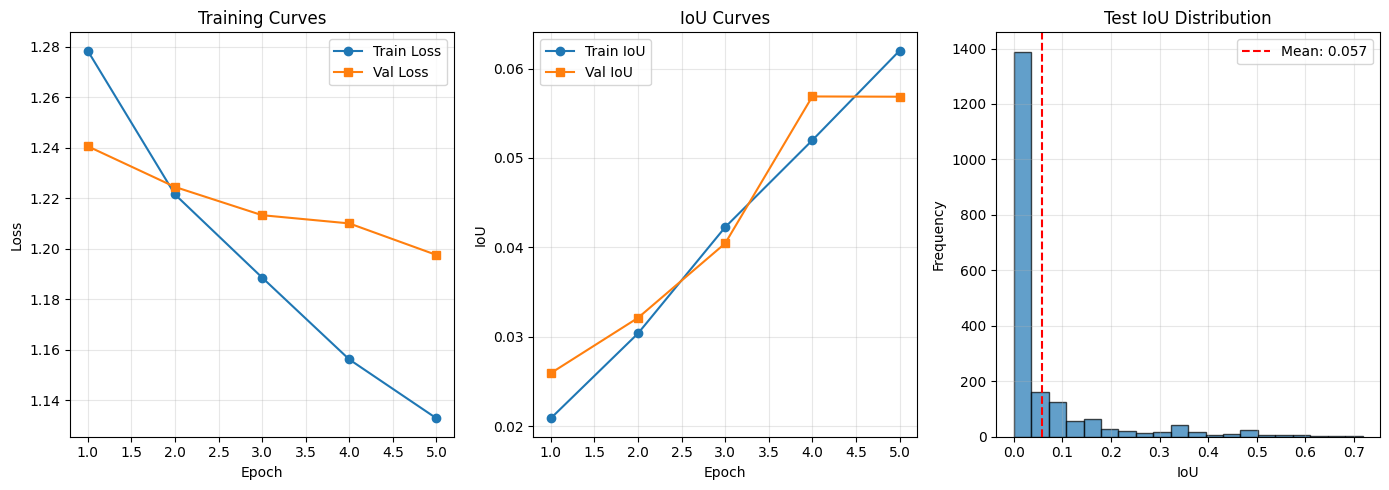

In [12]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel
import torch.nn.functional as F
import math

def pad_image_to_square(image, target_size=224, fill_color=(0, 0, 0)):
    """
    Pad image to square while maintaining aspect ratio.
    The entire image stays in frame with padding added.
    """
    w, h = image.size
    
    # Determine the longer dimension
    max_dim = max(w, h)
    
    # Calculate scaling to fit within target_size
    scale = target_size / max_dim
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    # Resize maintaining aspect ratio
    image = image.resize((new_w, new_h), Image.BILINEAR)
    
    # Create a square canvas with padding
    padded_image = Image.new('RGB', (target_size, target_size), fill_color)
    
    # Calculate padding to center the image
    paste_x = (target_size - new_w) // 2
    paste_y = (target_size - new_h) // 2
    
    # Paste the resized image onto the padded canvas
    padded_image.paste(image, (paste_x, paste_y))
    
    return padded_image, (paste_x, paste_y, new_w, new_h, scale)

class ScreenBoxDataset(Dataset):
    def __init__(self, df, image_folder, target_size=224):
        self.df = df.reset_index(drop=True)
        self.image_folder = image_folder
        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_folder, f"{row['screen_id']}.jpg")
        image = Image.open(image_path).convert("RGB")

        text = str(row["text"])

        # Get original image dimensions
        orig_w, orig_h = image.size

        # Pad image to square while maintaining aspect ratio
        padded_image, padding_info = pad_image_to_square(image, self.target_size)
        paste_x, paste_y, new_w, new_h, scale = padding_info

        # Dataset coordinates are normalized 0-999, convert to 0-1 in original image space
        orig_x1 = float(row["x1"]) / 999.0
        orig_y1 = float(row["y1"]) / 999.0
        orig_x2 = float(row["x2"]) / 999.0
        orig_y2 = float(row["y2"]) / 999.0
        
        # Convert from normalized [0,1] to absolute pixels in original image
        abs_x1 = orig_x1 * orig_w
        abs_y1 = orig_y1 * orig_h
        abs_x2 = orig_x2 * orig_w
        abs_y2 = orig_y2 * orig_h
        
        # Scale coordinates to the resized (but not yet padded) dimensions
        scaled_x1 = abs_x1 * scale
        scaled_y1 = abs_y1 * scale
        scaled_x2 = abs_x2 * scale
        scaled_y2 = abs_y2 * scale
        
        # Add padding offset (in absolute pixels on 224x224 canvas)
        padded_x1 = scaled_x1 + paste_x
        padded_y1 = scaled_y1 + paste_y
        padded_x2 = scaled_x2 + paste_x
        padded_y2 = scaled_y2 + paste_y
        
        # Normalize to [0,1] in the 224x224 space
        norm_x1 = padded_x1 / self.target_size
        norm_y1 = padded_y1 / self.target_size
        norm_x2 = padded_x2 / self.target_size
        norm_y2 = padded_y2 / self.target_size
        
        target = torch.tensor([
            norm_x1,
            norm_y1,
            norm_x2,
            norm_y2
        ], dtype=torch.float32)

        return {
            "image": padded_image,
            "text": text,
            "target": target,
            "screen_id": row["screen_id"]
        }

class BoundingBoxModel(nn.Module):
    def __init__(self,
                 clip_model_name="openai/clip-vit-base-patch32",
                 freeze_clip=True,
                 unfreeze_last_n_vision_layers=0,
                 unfreeze_last_n_text_layers=0,
                 device="cuda",
                 max_box_width=1,
                 max_box_height=1):
        super().__init__()
        self.device = device
        self.clip = CLIPModel.from_pretrained(clip_model_name)
        self.processor = CLIPProcessor.from_pretrained(clip_model_name)
        
        self.freeze_clip = freeze_clip
        self.unfreeze_last_n_vision_layers = unfreeze_last_n_vision_layers
        self.unfreeze_last_n_text_layers = unfreeze_last_n_text_layers

        self.max_box_width = max_box_width
        self.max_box_height = max_box_height

        embed_dim = self.clip.config.projection_dim

        # Freeze CLIP
        if self.freeze_clip:
            for param in self.clip.parameters():
                param.requires_grad = False
            
            # Unfreeze last N vision layers if specified
            if self.unfreeze_last_n_vision_layers > 0:
                vision_layers = self.clip.vision_model.encoder.layers
                for layer in vision_layers[-self.unfreeze_last_n_vision_layers:]:
                    for param in layer.parameters():
                        param.requires_grad = True
                print(f"Unfroze last {self.unfreeze_last_n_vision_layers} vision layers")
            
            # Unfreeze last N text layers if specified
            if self.unfreeze_last_n_text_layers > 0:
                text_layers = self.clip.text_model.encoder.layers
                for layer in text_layers[-self.unfreeze_last_n_text_layers:]:
                    for param in layer.parameters():
                        param.requires_grad = True
                print(f"Unfroze last {self.unfreeze_last_n_text_layers} text layers")

        # Fusion and prediction head
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 2, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1),
        )

        # Bounding box regression head
        self.bbox_head = nn.Linear(256, 4)

    def forward(self, images, texts, targets=None, visualize=False, batch_idx=0, loss_value=None):
        # Encode text
        text_inputs = self.processor(
            text=texts, 
            return_tensors="pt", 
            padding=True, 
            truncation=True
        ).to(self.device)
        
        with torch.set_grad_enabled(not self.freeze_clip or self.unfreeze_last_n_text_layers > 0):
            text_embeds = self.clip.get_text_features(**text_inputs)
        text_embeds = F.normalize(text_embeds, dim=-1)

        # Encode images (already 224x224 with padding)
        image_inputs = self.processor(
            images=images, 
            return_tensors="pt"
        ).to(self.device)
        
        with torch.set_grad_enabled(not self.freeze_clip or self.unfreeze_last_n_vision_layers > 0):
            image_embeds = self.clip.get_image_features(**image_inputs)
        image_embeds = F.normalize(image_embeds, dim=-1)

        # Combine image and text embeddings
        combined = torch.cat([image_embeds, text_embeds], dim=-1)
        features = self.fusion(combined)

        # Predict bounding box in center + size format
        bbox_params = self.bbox_head(features)
        
        # Convert to (x1, y1, x2, y2) format with sigmoid for [0,1] range
        cx = torch.sigmoid(bbox_params[:, 0])
        cy = torch.sigmoid(bbox_params[:, 1])
        w = torch.sigmoid(bbox_params[:, 2]) * self.max_box_width # Model tends to predict big boxes and doesn't learn so this will restrict size
        h = torch.sigmoid(bbox_params[:, 3]) * self.max_box_height
        
        # Convert center + size to corners
        x1 = cx - w / 2
        y1 = cy - h / 2
        x2 = cx + w / 2
        y2 = cy + h / 2
        
        # Clamp to [0, 1]
        x1 = torch.clamp(x1, 0, 1)
        y1 = torch.clamp(y1, 0, 1)
        x2 = torch.clamp(x2, 0, 1)
        y2 = torch.clamp(y2, 0, 1)
        
        bbox = torch.stack([x1, y1, x2, y2], dim=1)
        
        # Visualize with bounding boxes if requested
        if visualize and len(images) > 0 and targets is not None:
            import matplotlib.patches as patches
            
            num_imgs = min(4, len(images))
            fig, axes = plt.subplots(1, num_imgs, figsize=(5*num_imgs, 6))
            if num_imgs == 1:
                axes = [axes]
            
            # Move predictions to CPU for visualization
            pred_boxes_cpu = bbox.detach().cpu()
            targets_cpu = targets.cpu()
            
            for idx in range(num_imgs):
                ax = axes[idx] if num_imgs > 1 else axes[0]
                
                # Display image
                img_array = image_inputs['pixel_values'][idx].detach().permute(1, 2, 0).cpu().numpy()

                # Denormalize from CLIP's normalization
                mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 1, 3)
                std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 1, 3)
                img_array = img_array * std.numpy() + mean.numpy()
                img_array = torch.clamp(torch.tensor(img_array), 0, 1).numpy()
                
                ax.imshow(img_array)
                
                # Get bounding boxes in pixel coordinates (224x224)
                pred_box = pred_boxes_cpu[idx] * 224
                true_box = targets_cpu[idx] * 224
                
                # Draw ground truth box (green)
                x1, y1, x2, y2 = true_box
                width, height = x2 - x1, y2 - y1
                rect_true = patches.Rectangle(
                    (x1, y1), width, height,
                    linewidth=2, edgecolor='lime', facecolor='none',
                    label='Ground Truth'
                )
                ax.add_patch(rect_true)
                
                # Draw predicted box (red)
                x1, y1, x2, y2 = pred_box
                width, height = x2 - x1, y2 - y1
                rect_pred = patches.Rectangle(
                    (x1, y1), width, height,
                    linewidth=2, edgecolor='red', facecolor='none',
                    linestyle='--', label='Predicted'
                )
                ax.add_patch(rect_pred)
                
                # Calculate IoU for this sample
                iou = compute_iou(
                    pred_boxes_cpu[idx:idx+1],
                    targets_cpu[idx:idx+1]
                ).item()
                
                # Set title with text query and IoU
                text_short = texts[idx][:40] + "..." if len(texts[idx]) > 40 else texts[idx]
                ax.set_title(f'Batch {batch_idx}, Image {idx}\n"{text_short}"\nIoU: {iou:.3f}', 
                           fontsize=9)
                ax.axis('off')
                ax.legend(loc='upper right', fontsize=8)
            
            # Add overall batch statistics as suptitle
            if loss_value is not None:
                avg_iou = compute_iou(pred_boxes_cpu, targets_cpu).mean().item()
                fig.suptitle(f'Batch {batch_idx} | Train Loss: {loss_value:.4f} | Avg IoU: {avg_iou:.3f}', 
                           fontsize=12, fontweight='bold', y=0.98)
            
            plt.tight_layout()
            plt.subplots_adjust(top=0.92)  # Make room for suptitle
            plt.savefig(f'../results/batch_{batch_idx}_predictions.png')
            plt.close()
            print(f"        Saved visualization: batch_{batch_idx}_predictions.png")
        
        return bbox

class CIoULoss(nn.Module):
    """
    Compute CIoU loss
    """
    def __init__(self):
        super().__init__()
    
    def forward(self, pred_boxes, target_boxes, eps=1e-7):
        """
        Complete IoU Loss
        pred_boxes, target_boxes are (x1, y1, x2, y2) format, normalized [0,1]
        """
        pred_x1, pred_y1 = pred_boxes[:, 0], pred_boxes[:, 1]
        pred_x2, pred_y2 = pred_boxes[:, 2], pred_boxes[:, 3]
        target_x1, target_y1 = target_boxes[:, 0], target_boxes[:, 1]
        target_x2, target_y2 = target_boxes[:, 2], target_boxes[:, 3]
        
        # Calculate box centers
        pred_cx = (pred_x1 + pred_x2) / 2
        pred_cy = (pred_y1 + pred_y2) / 2
        target_cx = (target_x1 + target_x2) / 2
        target_cy = (target_y1 + target_y2) / 2
        
        # Calculate box widths and heights
        pred_w = pred_x2 - pred_x1
        pred_h = pred_y2 - pred_y1
        target_w = target_x2 - target_x1
        target_h = target_y2 - target_y1
        
        # Intersection
        x1_inter = torch.max(pred_x1, target_x1)
        y1_inter = torch.max(pred_y1, target_y1)
        x2_inter = torch.min(pred_x2, target_x2)
        y2_inter = torch.min(pred_y2, target_y2)
        
        inter_area = (
            torch.clamp(x2_inter - x1_inter, min=0) * 
            torch.clamp(y2_inter - y1_inter, min=0)
        )
        
        # Union
        pred_area = pred_w * pred_h
        target_area = target_w * target_h
        union_area = pred_area + target_area - inter_area + eps
        
        # IoU
        iou = inter_area / union_area
        
        # Enclosing box (smallest box containing both pred and target)
        x1_enclosing = torch.min(pred_x1, target_x1)
        y1_enclosing = torch.min(pred_y1, target_y1)
        x2_enclosing = torch.max(pred_x2, target_x2)
        y2_enclosing = torch.max(pred_y2, target_y2)
        
        # Diagonal of enclosing box
        c_w = x2_enclosing - x1_enclosing
        c_h = y2_enclosing - y1_enclosing
        c2 = c_w ** 2 + c_h ** 2 + eps  # squared diagonal distance
        
        # Distance between centers
        rho2 = (pred_cx - target_cx) ** 2 + (pred_cy - target_cy) ** 2
        
        # Aspect ratio consistency term
        arctan_pred = torch.atan(pred_w / (pred_h + eps))
        arctan_target = torch.atan(target_w / (target_h + eps))
        v = (4 / (math.pi ** 2)) * torch.pow(arctan_pred - arctan_target, 2)
        
        # Alpha weighting factor (makes aspect ratio term adaptive)
        with torch.no_grad():
            alpha = v / (1 - iou + v + eps)
        
        # Complete IoU
        ciou = iou - (rho2 / c2) - alpha * v
        
        # CIoU loss
        loss = 1 - ciou
        return loss.mean()

def compute_iou(box1, box2, eps=1e-7):
    """Compute IoU between two sets of boxes (normalized coordinates)"""
    box1_x1, box1_y1, box1_x2, box1_y2 = box1[:, 0], box1[:, 1], box1[:, 2], box1[:, 3]
    box2_x1, box2_y1, box2_x2, box2_y2 = box2[:, 0], box2[:, 1], box2[:, 2], box2[:, 3]
    
    x1_inter = torch.max(box1_x1, box2_x1)
    y1_inter = torch.max(box1_y1, box2_y1)
    x2_inter = torch.min(box1_x2, box2_x2)
    y2_inter = torch.min(box1_y2, box2_y2)
    
    inter_area = (
        torch.clamp(x2_inter - x1_inter, min=0) * 
        torch.clamp(y2_inter - y1_inter, min=0)
    )
    
    box1_area = (box1_x2 - box1_x1) * (box1_y2 - box1_y1)
    box2_area = (box2_x2 - box2_x1) * (box2_y2 - box2_y1)
    union_area = box1_area + box2_area - inter_area + eps
    
    iou = inter_area / union_area
    return iou

# Data preparation
csv_path = "../data/screen_annotation/extracted_annotations.csv"
image_folder = "../data/screen_annotation/images"

df = pd.read_csv(csv_path).iloc[:10000, :] # USING PART OF SET FOR INITIAL TRAINING

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
train_size = int(0.7 * len(df))
val_size = int(0.1 * len(df))

train_df = df[:train_size]
val_df = df[train_size:train_size + val_size]
test_df = df[train_size + val_size:]

train_dataset = ScreenBoxDataset(train_df, image_folder, target_size=224)
val_dataset = ScreenBoxDataset(val_df, image_folder, target_size=224)
test_dataset = ScreenBoxDataset(test_df, image_folder, target_size=224)

def collate_fn(batch):
    return {
        'image': [item['image'] for item in batch],
        'text': [item['text'] for item in batch],
        'target': torch.stack([item['target'] for item in batch]),
        'screen_id': [item['screen_id'] for item in batch]
    }

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# Training setup
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BoundingBoxModel(
    device=device,
    freeze_clip=True,
    unfreeze_last_n_vision_layers=4,
    unfreeze_last_n_text_layers=4,
    max_box_width=0.25,
    max_box_height=0.25
).to(device)

criterion = CIoULoss()

# Build parameter groups with different learning rates
param_groups = []

# Prediction heads (higher learning rate)
head_params = list(model.fusion.parameters()) + list(model.bbox_head.parameters())
param_groups.append({'params': head_params, 'lr': 1e-4, 'name': 'heads'})

# Unfrozen vision layers (low learning rate for fine-tuning)
if UNFREEZE_VISION_LAYERS > 0:
    vision_layers = model.clip.vision_model.encoder.layers[-UNFREEZE_VISION_LAYERS:]
    vision_params = []
    for layer in vision_layers:
        vision_params.extend(list(layer.parameters()))
    param_groups.append({'params': vision_params, 'lr': 1e-5, 'name': 'vision'})
    print(f"Added {len(vision_params)} vision parameters for fine-tuning")

# Unfrozen text layers (low learning rate for fine-tuning)
if UNFREEZE_TEXT_LAYERS > 0:
    text_layers = model.clip.text_model.encoder.layers[-UNFREEZE_TEXT_LAYERS:]
    text_params = []
    for layer in text_layers:
        text_params.extend(list(layer.parameters()))
    param_groups.append({'params': text_params, 'lr': 1e-5, 'name': 'text'})
    print(f"Added {len(text_params)} text parameters for fine-tuning")

# Optimizer
optimizer = torch.optim.AdamW(param_groups, weight_decay=0.01)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max', # Maximize IoU
    factor=0.5,
    patience=3
)

# Training
num_epochs = 5
best_val_iou = 0.0
patience = 2
patience_counter = 0

epoch_train_losses, epoch_val_losses = [], []
epoch_train_ious, epoch_val_ious = [], []

# Variables for visualizing predictions (batch progress)
VISUALIZE_BATCHES = True
VISUALIZE_EVERY_N_BATCHES = 20  # Visualize every N batches

for epoch in range(num_epochs):
    model.train()
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch [{epoch+1}/{num_epochs}] - LR: {current_lr:.2e}")
    
    train_losses, train_ious = [], []
    
    for i, batch in enumerate(train_loader, start=0):
        if i % 10 == 0:
            print(f"    Batch {i}/{len(train_loader)-1}")
        
        images = batch["image"]
        texts = batch["text"]
        targets = batch["target"].to(device)

        # Visualize images in forward pass
        should_visualize = VISUALIZE_BATCHES and i % VISUALIZE_EVERY_N_BATCHES == 0
        
        pred_boxes = model(images, texts, targets=targets, visualize=False, batch_idx=i)
        
        loss = criterion(pred_boxes, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            iou = compute_iou(pred_boxes, targets)
            train_ious.append(iou.mean().item())
        
        train_losses.append(loss.item())
        
        # Visualize after computing loss
        if should_visualize:
            with torch.no_grad():
                pred_boxes_vis = model(images, texts, targets=targets, 
                                     visualize=True, batch_idx=i, loss_value=loss.item())
    
    avg_train_loss = sum(train_losses) / len(train_losses)
    avg_train_iou = sum(train_ious) / len(train_ious)
    print(f"    Train Loss: {avg_train_loss:.4f}, Train IoU: {avg_train_iou:.4f}")

    # Validation
    model.eval()
    val_losses, val_ious = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"]
            texts = batch["text"]
            targets = batch["target"].to(device)
            
            pred_boxes = model(images, texts)
            loss = criterion(pred_boxes, targets)
            iou = compute_iou(pred_boxes, targets)
            
            val_losses.append(loss.item())
            val_ious.append(iou.mean().item())
    
    mean_val_loss = sum(val_losses) / len(val_losses)
    mean_val_iou = sum(val_ious) / len(val_ious)
    print(f"    Val Loss: {mean_val_loss:.4f}, Val IoU: {mean_val_iou:.4f}")
    
    # Step scheduler
    scheduler.step(mean_val_iou)
    
    # Save best model
    if mean_val_iou > best_val_iou:
        best_val_iou = mean_val_iou
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': mean_val_loss,
            'val_iou': mean_val_iou,
        }, '../src/best_bounding_box_model.pth')
        print(f"    Best model saved! (Val IoU: {best_val_iou:.4f})")
    else:
        patience_counter += 1
        print(f"    No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"    Early stopping triggered after {epoch+1} epochs")
            break

    epoch_train_losses.append(avg_train_loss)
    epoch_val_losses.append(mean_val_loss)
    epoch_train_ious.append(avg_train_iou)
    epoch_val_ious.append(mean_val_iou)

print("\n" + "="*50)
print("FINAL TEST EVALUATION")
print("="*50)

checkpoint = torch.load('../src/best_bounding_box_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best validation IoU: {checkpoint['val_iou']:.4f}")

model.eval()
test_losses, test_ious = [], []

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"]
        texts = batch["text"]
        targets = batch["target"].to(device)
        
        pred_boxes = model(images, texts)
        loss = criterion(pred_boxes, targets)
        iou = compute_iou(pred_boxes, targets)
        
        test_losses.append(loss.item())
        test_ious.extend(iou.cpu().tolist())

mean_test_loss = sum(test_losses) / len(test_losses)
mean_test_iou = sum(test_ious) / len(test_ious)

print(f"Test Loss: {mean_test_loss:.4f}")
print(f"Test IoU (mean): {mean_test_iou:.4f}")
print(f"Test IoU (median): {sorted(test_ious)[len(test_ious)//2]:.4f}")

# Visualization
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, len(epoch_train_losses)+1), epoch_train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(epoch_val_losses)+1), epoch_val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(range(1, len(epoch_train_ious)+1), epoch_train_ious, label='Train IoU', marker='o')
plt.plot(range(1, len(epoch_val_ious)+1), epoch_val_ious, label='Val IoU', marker='s')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('IoU Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(test_ious, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('IoU')
plt.ylabel('Frequency')
plt.title('Test IoU Distribution')
plt.axvline(mean_test_iou, color='r', linestyle='--', label=f'Mean: {mean_test_iou:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_results.png')
print("\nTraining complete! Results saved to 'training_results.png'")